In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches

In [1]:
from google.colab import files

uploaded = files.upload()

Saving July-2026-CSV-Trf28h (2).csv to July-2026-CSV-Trf28h (2).csv


In [3]:
import pandas as pd

ae_data = pd.read_csv('/content/July-2026-CSV-Trf28h (2).csv')

ae_data.head()

,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,...,Attendances over 4hrs Other Department,Attendances over 4hrs Booked Appointments Type 1,Attendances over 4hrs Booked Appointments Type 2,Attendances over 4hrs Booked Appointments Other Department,Patients who have waited 4-12 hs from DTA to admission,Patients who have waited 12+ hrs from DTA to admission,Emergency admissions via A&E - Type 1,Emergency admissions via A&E - Type 2,Emergency admissions via A&E - Other A&E department,Other emergency admissions
0,MSitAE-JULY-2026,AAH,NHS ENGLAND SOUTH WEST,TETBURY HOSPITAL TRUST LTD,0,0,791,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,MSitAE-JULY-2026,NDJ,NHS ENGLAND SOUTH EAST,FIRST COMMUNITY HEALTH AND CARE CIC,0,0,2637,0,0,0,...,73,0,0,0,0,0,0,0,0,0
2,MSitAE-JULY-2026,RBQ,NHS ENGLAND NORTH WEST,LIVERPOOL HEART AND CHEST HOSPITAL NHS FOUNDAT...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,91
3,MSitAE-JULY-2026,RBT,NHS ENGLAND NORTH WEST,MID CHESHIRE HOSPITALS NHS FOUNDATION TRUST,7393,0,3469,0,0,105,...,30,0,0,0,478,513,2504,0,0,751
4,MSitAE-JULY-2026,RDU,NHS ENGLAND SOUTH EAST,FRIMLEY HEALTH NHS FOUNDATION TRUST,24005,1028,12063,0,0,0,...,189,0,0,0,1233,538,6610,0,0,166


 The head() function displays the first five rows of the dataset. This provides an initial overview of how the data is structured and allows me to check that the CSV file has been imported correctly before beginning the analysis.

In [4]:
ae_data.shape

(192, 22)

The shape attribute returns the number of rows and columns in the dataset. The dataset contains 192 rows and 22 columns, meaning there are 192 provider records and 22 variables describing A&E activity and performance.

In [5]:
ae_data.columns.tolist()

['Period',
 'Org Code',
 'Parent Org',
 'Org name',
 'A&E attendances Type 1',
 'A&E attendances Type 2',
 'A&E attendances Other A&E Department',
 'A&E attendances Booked Appointments Type 1',
 'A&E attendances Booked Appointments Type 2',
 'A&E attendances Booked Appointments Other Department',
 'Attendances over 4hrs Type 1',
 'Attendances over 4hrs Type 2',
 'Attendances over 4hrs Other Department',
 'Attendances over 4hrs Booked Appointments Type 1',
 'Attendances over 4hrs Booked Appointments Type 2',
 'Attendances over 4hrs Booked Appointments Other Department',
 'Patients who have waited 4-12 hs from DTA to admission',
 'Patients who have waited 12+ hrs from DTA to admission',
 'Emergency admissions via A&E - Type 1',
 'Emergency admissions via A&E - Type 2',
 'Emergency admissions via A&E - Other A&E department',
 'Other emergency admissions']

The column names were inspected to understand which variables are available for analysis. The dataset contains information on A&E attendances, four-hour breaches, booked appointments, delays following a decision to admit, and emergency admissions.

This step helps identify which variables will be relevant when calculating performance measures and building the final dashboard.

In [6]:
ae_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 22 columns):
 #   Column                                                      Non-Null Count  Dtype 
---  ------                                                      --------------  ----- 
 0   Period                                                      192 non-null    object
 1   Org Code                                                    192 non-null    object
 2   Parent Org                                                  192 non-null    object
 3   Org name                                                    192 non-null    object
 4   A&E attendances Type 1                                      192 non-null    int64 
 5   A&E attendances Type 2                                      192 non-null    int64 
 6   A&E attendances Other A&E Department                        192 non-null    int64 
 7   A&E attendances Booked Appointments Type 1                  192 non-null    int64 
 8   A&E attend

The info() function was used to inspect the structure of the dataset, including data types and missing values.

The dataset contains 192 complete records with no missing values. Eighteen columns contain numerical data stored as integers, while four columns contain text-based information such as the reporting period, organisation code and organisation name.

This confirms that the main activity variables are already stored in a suitable numerical format for analysis.

In [7]:
ae_data['Period'].value_counts()

,count
Period,
MSitAE-JULY-2026,191
Total,1


The value_counts() function was used to examine the values contained within the Period column. This confirms which reporting period the provider-level records relate to and checks whether the dataset contains data from a single month or multiple reporting periods.

**Result**: The dataset contains 191 records labelled MSitAE-JULY-2026 and one summary row labelled Total. The total row will be removed before provider-level analysis to prevent national totals from being treated as an individual provider.

In [8]:
ae_clean = ae_data[ae_data['Period'] != 'Total'].copy()

ae_clean.shape

(191, 22)

The dataset contained one national summary row labelled Total. This row was removed because the analysis focuses on comparisons between individual NHS providers. Including the national total as though it were a provider would distort calculations such as rankings, averages and visualisations.

In [9]:
ae_clean['Org Code'].duplicated().sum()

np.int64(0)

Duplicate Provider Check

The duplicated() function was used on the organisation code column to identify whether any NHS provider appeared more than once in the dataset. Organisation codes are used because they provide a unique identifier for each provider and are more reliable than organisation names alone.

The .sum() function counts how many duplicate organisation codes are present.

Result: No duplicate provider records were identified, so no further duplicate removal was required.

In [10]:
ae_clean['Total A&E Attendances'] = (
ae_clean['A&E attendances Type 1']
+ ae_clean['A&E attendances Type 2']
+ ae_clean['A&E attendances Other A&E Department']
)

ae_clean[['Org name', 'Total A&E Attendances']].head()

,Org name,Total A&E Attendances
0,TETBURY HOSPITAL TRUST LTD,791
1,FIRST COMMUNITY HEALTH AND CARE CIC,2637
2,LIVERPOOL HEART AND CHEST HOSPITAL NHS FOUNDAT...,0
3,MID CHESHIRE HOSPITALS NHS FOUNDATION TRUST,10862
4,FRIMLEY HEALTH NHS FOUNDATION TRUST,37096


A new variable called Total A&E Attendances was created by summing attendances across Type 1, Type 2 and other A&E departments for each provider.

This provides a single measure of overall A&E activity and will allow providers to be compared by total demand rather than by individual department type.

Type 1 = major A&E departments

Type 2 = specialist A&E departments

Other A&E = urgent treatment centres and other departments

In [11]:
ae_clean['Total A&E Attendances'].sum()

np.int64(2411415)

In [12]:
ae_clean['Total A&E Attendances'] = (
ae_clean['A&E attendances Type 1'] +
ae_clean['A&E attendances Type 2'] +
ae_clean['A&E attendances Other A&E Department'] +
ae_clean['A&E attendances Booked Appointments Type 1'] +
ae_clean['A&E attendances Booked Appointments Type 2'] +
ae_clean['A&E attendances Booked Appointments Other Department']
)
ae_clean['Total A&E Attendances'].sum()

np.int64(2487580)

**Calculating and Validating Total A&E Attendances**

A new variable called *Total A&E Attendances* was calculated by combining attendances across Type 1, Type 2 and other A&E departments, including booked appointments.

An initial calculation excluding booked appointments produced 2,411,415 attendances. This was compared with the official NHS England July 2026 total of 2,487,580. The difference of 76,165 matched the number of booked A&E appointments reported by NHS England, showing that booked appointments also needed to be included in the calculation.

After including these variables, the calculated total was validated against the published NHS England figure.

In [13]:
ae_clean['Total Over 4 Hours'] = (

ae_clean['Attendances over 4hrs Type 1'] +

ae_clean['Attendances over 4hrs Type 2'] +

ae_clean['Attendances over 4hrs Other Department'] +

ae_clean['Attendances over 4hrs Booked Appointments Type 1'] +

ae_clean['Attendances over 4hrs Booked Appointments Type 2'] +

ae_clean['Attendances over 4hrs Booked Appointments Other Department']

)

ae_clean['Total Over 4 Hours'].sum()

np.int64(612579)

**Calculating Total Four-Hour Breaches**

The NHS dataset reports attendances lasting over four hours separately by department type and booked appointment status. These variables were combined to create a single Total Over 4 Hours measure for each provider.

This allows four-hour performance to be compared consistently across providers and will later be used to calculate the percentage of patients admitted, transferred or discharged within four hours.

The NHS July 2026 commentary reports 1,875,001 attendances within four hours out of 2,487,580 total attendances, so we expect roughly 612,579 attendances over four hours.

In [14]:
ae_clean['Within 4 Hours'] = ae_clean['Total A&E Attendances'] - ae_clean['Total Over 4 Hours']

ae_clean['4 Hour Performance %'] = (

ae_clean['Within 4 Hours'] / ae_clean['Total A&E Attendances']

) * 100

ae_clean[['Org name', 'Total A&E Attendances', 'Within 4 Hours', '4 Hour Performance %']].head()

,Org name,Total A&E Attendances,Within 4 Hours,4 Hour Performance %
0,TETBURY HOSPITAL TRUST LTD,791,791,100.000000
1,FIRST COMMUNITY HEALTH AND CARE CIC,2637,2564,97.231703
2,LIVERPOOL HEART AND CHEST HOSPITAL NHS FOUNDAT...,0,0,NaN
3,MID CHESHIRE HOSPITALS NHS FOUNDATION TRUST,10967,7260,66.198596
4,FRIMLEY HEALTH NHS FOUNDATION TRUST,37096,27470,74.051111


The number of attendances completed within four hours was calculated by subtracting four-hour breaches from total A&E attendances.

A four-hour performance percentage was then calculated for each provider by dividing the number of attendances completed within four hours by total attendances and multiplying by 100.

This provides a standardised measure that allows A&E performance to be compared between providers of different sizes.

The NHS operational standard is that 95% of patients should be admitted, transferred or discharged within four hours.


In [15]:
(ae_clean['Within 4 Hours'].sum() / ae_clean['Total A&E Attendances'].sum()) * 100

np.float64(75.37450051857628)

**Validation**: The calculated national four hour performance was 75.37%, which rounds to 75.4% and matches the figure published by NHS England for July 2026. This confirms that the attendance and four hour breach calculations have been constructed correctly.

In [16]:
ae_clean['Total Emergency Admissions'] = (

ae_clean['Emergency admissions via A&E - Type 1'] +

ae_clean['Emergency admissions via A&E - Type 2'] +

ae_clean['Emergency admissions via A&E - Other A&E department'] +

ae_clean['Other emergency admissions']

)

ae_clean['Total Emergency Admissions'].sum()

np.int64(547828)

**Calculating Total Emergency Admissions**

Emergency admissions are reported separately according to whether patients were admitted through Type 1, Type 2 or other A&E departments, as well as emergency admissions originating from other routes.

These variables were combined to create a single Total Emergency Admissions measure for each provider. This allows overall emergency admission activity to be compared between NHS organisations.

We can validate this again. NHS England reports 547,828 emergency admissions in July 2026.

**Validation**: The calculated total of 547,828 emergency admissions exactly matched the official NHS England July 2026 figure, confirming that the relevant admission categories were combined correctly.

In [17]:
ae_clean['Total DTA Over 4 Hours'] = (

ae_clean['Patients who have waited 4-12 hs from DTA to admission'] +

ae_clean['Patients who have waited 12+ hrs from DTA to admission']

)

ae_clean['Total DTA Over 4 Hours'].sum()

np.int64(124744)

**Calculating Delays Following a Decision to Admit**

Patients who require hospital admission may experience an additional delay after the clinical decision to admit has been made. The dataset reports these delays separately for waits of 4 to 12 hours and waits of 12 hours or more.

These variables were combined to calculate the total number of patients experiencing a delay of more than four hours from decision to admit to admission for each provider.

This provides an additional measure of pressure within emergency care because it reflects delays in moving patients from A&E into an inpatient hospital bed.

NHS England reports 124,744 delays of more than four hours from decision to admit in July 2026, including 47,438 waits of 12 hours or more.

**Validation**: The calculated total of 124,744 patients waiting more than four hours from decision to admit exactly matched the official NHS England July 2026 figure.

In [18]:
(ae_clean['Total A&E Attendances'] == 0).sum()

np.int64(9)

**Checking for Providers with No A&E Activity**

Before comparing provider performance, the dataset was checked for organisations with zero total A&E attendances.

Providers with no recorded attendance activity cannot have a meaningful four hour performance percentage because this would require division by zero. Identifying these records ensures that subsequent provider rankings are based only on valid performance data.

Run that and send me the number you get.

In [19]:
ae_clean.loc[ae_clean['Total A&E Attendances'] == 0, ['Org Code', 'Org name', 'Total A&E Attendances']]

,Org Code,Org name,Total A&E Attendances
2,RBQ,LIVERPOOL HEART AND CHEST HOSPITAL NHS FOUNDAT...,0
5,RJ8,CORNWALL PARTNERSHIP NHS FOUNDATION TRUST,0
23,RAN,ROYAL NATIONAL ORTHOPAEDIC HOSPITAL NHS TRUST,0
26,RET,THE WALTON CENTRE NHS FOUNDATION TRUST,0
29,RXG,SOUTH WEST YORKSHIRE PARTNERSHIP TEACHING NHS ...,0
41,RDY,DORSET HEALTHCARE UNIVERSITY NHS FOUNDATION TRUST,0
76,RL1,THE ROBERT JONES AND AGNES HUNT ORTHOPAEDIC HO...,0
140,RBV,THE CHRISTIE NHS FOUNDATION TRUST,0
169,RYG,COVENTRY AND WARWICKSHIRE PARTNERSHIP NHS TRUST,0


**Reviewing Providers with Zero A&E Attendances**

Nine provider records were identified with zero total A&E attendances. These records were inspected before exclusion to determine whether they represented data-quality issues or organisations that legitimately reported no A&E activity during July 2026.

This step is important because records should not be removed automatically without first understanding why they contain zero activity.

Send me the names of the 9 providers that appear.

Then we’ll decide how to handle them before doing best and worst provider rankings.

**Resetting the DataFrame Index**

After filtering the dataset, the original row index was retained. The reset_index() function was used to create a new sequential index for the cleaned dataset.

The drop=True argument prevents the old index from being added as an additional column.

In [20]:
ae_performance = ae_clean[ae_clean['Total A&E Attendances'] > 0].copy()

ae_performance.shape

(182, 28)

**Creating the A&E Performance Analysis Dataset**

Nine providers recorded zero A&E attendances during July 2026. These organisations were retained in the cleaned master dataset but excluded from provider-level A&E performance comparisons.

A separate dataframe called ae_performance was created containing only providers with at least one recorded A&E attendance.

This prevents organisations with no A&E activity from producing invalid or misleading performance percentages while preserving the original cleaned data for other analyses.

In [21]:
worst_10 = ae_performance.sort_values('4 Hour Performance %').head(10)

worst_10[['Org name', 'Total A&E Attendances', '4 Hour Performance %']]

,Org name,Total A&E Attendances,4 Hour Performance %
108,THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST,14495,52.176613
92,EAST CHESHIRE NHS TRUST,4860,53.744856
86,ROYAL UNITED HOSPITALS BATH NHS FOUNDATION TRUST,9191,56.152758
6,SURREY AND SUSSEX HEALTHCARE NHS TRUST,10600,56.990566
185,AIREDALE NHS FOUNDATION TRUST,7169,59.157484
174,WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDA...,11625,59.690323
93,COUNTESS OF CHESTER HOSPITAL NHS FOUNDATION TRUST,8847,61.184582
105,HULL UNIVERSITY TEACHING HOSPITALS NHS TRUST,14828,62.233612
65,UNIVERSITY HOSPITALS SUSSEX NHS FOUNDATION TRUST,35058,62.445091
115,YORK AND SCARBOROUGH TEACHING HOSPITALS NHS FO...,19896,62.520105


**Identifying Providers with the Lowest Four-Hour Performance**

Providers were ranked according to their calculated four-hour performance percentage using the sort_values() function.

The ten providers with the lowest performance were selected for initial comparison. Total A&E attendance was displayed alongside performance to provide context regarding the level of activity handled by each organisation.

This analysis provides an initial indication of which providers experienced the greatest difficulty meeting the four-hour A&E standard during July 2026.

In [22]:
ae_clean['Type 1 Total Attendances'] = ae_clean['A&E attendances Type 1'] + ae_clean['A&E attendances Booked Appointments Type 1']

ae_clean['Type 1 Over 4 Hours'] = ae_clean['Attendances over 4hrs Type 1'] + ae_clean['Attendances over 4hrs Booked Appointments Type 1']

ae_clean['Type 1 Within 4 Hours'] = ae_clean['Type 1 Total Attendances'] - ae_clean['Type 1 Over 4 Hours']

ae_clean['Type 1 4 Hour Performance %'] = (ae_clean['Type 1 Within 4 Hours'] / ae_clean['Type 1 Total Attendances']) * 100

(ae_clean['Type 1 Within 4 Hours'].sum() / ae_clean['Type 1 Total Attendances'].sum()) * 100

np.float64(61.7135124553354)

**Calculating Type 1 A&E Performance**

Overall A&E performance combines several types of emergency care service. To make provider comparisons more meaningful, a separate performance measure was calculated for Type 1 departments, which represent major consultant-led 24-hour A&E services.

Type 1 attendances and booked appointments were combined, along with their corresponding four-hour breaches. The number completed within four hours was then divided by total Type 1 attendance to calculate a provider-level four-hour performance percentage.

This allows major emergency departments to be compared more consistently without differences in urgent treatment centre activity affecting the ranking.

**Validation**: The calculated national Type 1 four-hour performance was 61.71%, which rounds to 61.7% and matches the official NHS England figure for July 2026. This confirms that the Type 1 attendance and breach calculations were constructed correctly.

In [23]:
ae_type1 = ae_clean[ae_clean['Type 1 Total Attendances'] > 0].copy()

ae_type1.shape

(120, 32)

**Creating the Type 1 Provider Dataset**

A separate dataframe called ae_type1 was created containing only organisations with recorded Type 1 A&E activity.

Providers without a major Type 1 emergency department were excluded from this comparison because their Type 1 performance percentage would not be meaningful.

This creates a more appropriate dataset for comparing the performance of major hospital emergency departments.

In [24]:
worst_10_type1 = ae_type1.sort_values('Type 1 4 Hour Performance %').head(10).reset_index(drop=True)

worst_10_type1[['Org name', 'Type 1 Total Attendances', 'Type 1 4 Hour Performance %']]

,Org name,Type 1 Total Attendances,Type 1 4 Hour Performance %
0,UNIVERSITY HOSPITALS PLYMOUTH NHS TRUST,9411,37.094889
1,NORTH TEES AND HARTLEPOOL NHS FOUNDATION TRUST,5306,41.160950
2,ROYAL CORNWALL HOSPITALS NHS TRUST,8176,43.334149
3,THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST,12003,44.572190
4,LEWISHAM AND GREENWICH NHS TRUST,16455,44.655120
5,NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST,13359,44.733887
6,CHESTERFIELD ROYAL HOSPITAL NHS FOUNDATION TRUST,7163,45.944437
7,WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDA...,8631,46.008574
8,HAMPSHIRE HOSPITALS NHS FOUNDATION TRUST,10368,46.759259
9,KINGSTON AND RICHMOND NHS FOUNDATION TRUST,7230,47.053942


**Lowest Performing Type 1 A&E Providers**

Type 1 providers were ranked according to their four-hour performance percentage. The ten organisations with the lowest performance were selected to identify major emergency departments experiencing the greatest difficulty meeting the four-hour standard during July 2026.

Total Type 1 attendances were included alongside performance percentages to provide context regarding the volume of patients handled by each provider.

The analysis was restricted to organisations with recorded Type 1 activity to ensure that comparisons were made between major consultant-led A&E departments.

**Result**: University Hospitals Plymouth NHS Trust recorded the lowest Type 1 four hour performance in July 2026 at approximately 37.1%. All ten of the lowest ranked providers recorded performance below 48%, substantially below the NHS operational standard of 95%.

In [25]:
best_10_type1 = ae_type1.sort_values('Type 1 4 Hour Performance %', ascending=False).head(10).reset_index(drop=True)

best_10_type1[['Org name', 'Type 1 Total Attendances', 'Type 1 4 Hour Performance %']]

,Org name,Type 1 Total Attendances,Type 1 4 Hour Performance %
0,SHEFFIELD CHILDREN'S NHS FOUNDATION TRUST,4860,91.399177
1,GEORGE ELIOT HOSPITAL NHS TRUST,7469,89.369393
2,ALDER HEY CHILDREN'S NHS FOUNDATION TRUST,5798,88.737496
3,CALDERDALE AND HUDDERSFIELD NHS FOUNDATION TRUST,17089,85.066417
4,BIRMINGHAM WOMEN'S AND CHILDREN'S NHS FOUNDATI...,4528,83.856007
5,NORTHUMBRIA HEALTHCARE NHS FOUNDATION TRUST,11136,81.357759
6,HOMERTON HEALTHCARE NHS FOUNDATION TRUST,11507,79.064917
7,UNIVERSITY COLLEGE LONDON HOSPITALS NHS FOUNDA...,14726,75.940513
8,WEST HERTFORDSHIRE TEACHING HOSPITALS NHS TRUST,8493,75.285529
9,BARNSLEY HOSPITAL NHS FOUNDATION TRUST,10287,74.219889


**Highest Performing Type 1 A&E Providers**

Type 1 providers were ranked from highest to lowest according to their four hour performance percentage.

The ten organisations with the highest performance were selected to provide a comparison with the lowest-performing providers. Total Type 1 attendance was retained alongside the performance percentage to provide context regarding provider activity.

Comparing both ends of the distribution helps identify the variation in A&E performance between major NHS emergency departments during July 2026.

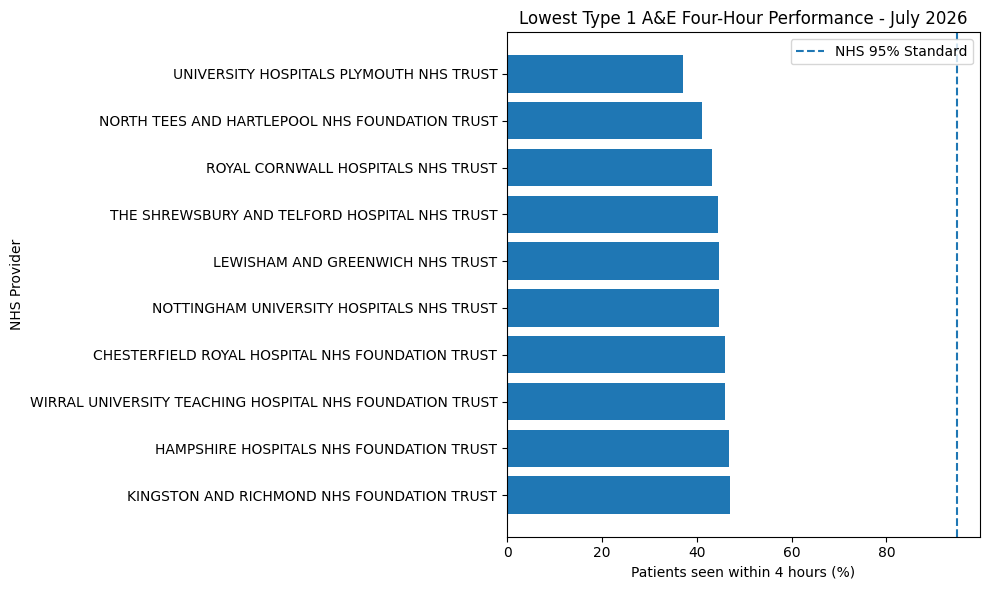

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(worst_10_type1['Org name'], worst_10_type1['Type 1 4 Hour Performance %'])

plt.axvline(x=95, linestyle='--', label='NHS 95% Standard')

plt.xlabel('Patients seen within 4 hours (%)')

plt.ylabel('NHS Provider')

plt.title('Lowest Type 1 A&E Four-Hour Performance - July 2026')

plt.gca().invert_yaxis()

plt.legend()

plt.tight_layout()

plt.show()

plt.figure(figsize=(10, 6)) creates the space for the graph.

plt.barh() makes a horizontal bar chart, which works better because the hospital names are long.

plt.axvline(x=95...) shows the NHS 95% standard as a reference line.

invert_yaxis() makes the lowest-performing provider appear at the top rather than the bottom.

tight_layout() stops labels from being cut off.



**Visualising the Lowest Type 1 A&E Performance**

A horizontal bar chart was created to compare the ten Type 1 providers with the lowest four-hour performance during July 2026.

A reference line representing the NHS operational standard of 95% was included to provide context for provider performance.

The horizontal format was selected because provider names are relatively long and can be displayed more clearly than on a vertical bar chart.

The visualisation shows substantial variation among the lowest-performing Type 1 providers, with all ten recording fewer than half of attendances within four hours.

In [27]:
correlation = ae_type1['Type 1 Total Attendances'].corr(ae_type1['Type 1 4 Hour Performance %'])

correlation

np.float64(0.05472230117912442)

**Here we are comparing:**

Type 1 Total Attendances

with

Type 1 Four Hour Performance %

The result will be between -1 and +1.

**Relationship Between A&E Demand and Four Hour Performance**

A Pearson correlation coefficient was calculated to explore whether the volume of Type 1 A&E attendances was associated with four hour performance across NHS providers.

Total Type 1 attendance was used as an indicator of A&E activity, while the calculated four hour performance percentage represented provider performance.

The correlation coefficient ranges from −1 to +1. Negative values indicate that higher attendance is associated with lower performance, while positive values indicate that higher attendance is associated with higher performance. Values closer to zero indicate a weaker linear relationship.

This analysis identifies association rather than causation, as A&E performance may also be influenced by factors such as capacity, staffing, patient complexity and hospital flow.

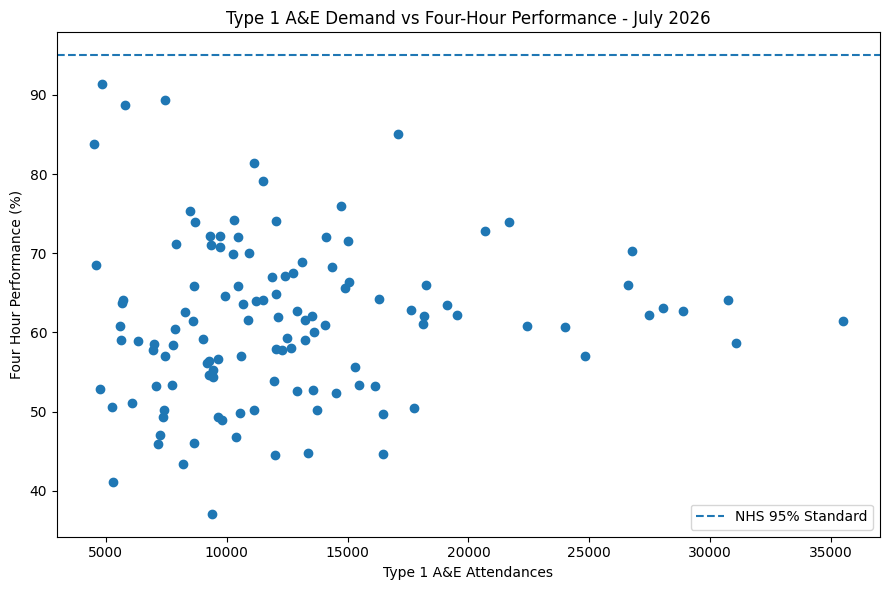

In [28]:
plt.figure(figsize=(9, 6))

plt.scatter(ae_type1['Type 1 Total Attendances'], ae_type1['Type 1 4 Hour Performance %'])

plt.axhline(y=95, linestyle='--', label='NHS 95% Standard')

plt.xlabel('Type 1 A&E Attendances')

plt.ylabel('Four Hour Performance (%)')

plt.title('Type 1 A&E Demand vs Four-Hour Performance - July 2026')

plt.legend()

plt.tight_layout()

plt.show()

**Result**: The scatter plot shows no clear relationship between Type 1 attendance volume and four hour performance. This supports the correlation coefficient of 0.055, suggesting that higher patient volumes alone were not strongly associated with poorer performance in July 2026. All providers were also below the NHS 95% operational standard.

In [29]:
ae_clean['Emergency Admissions via A&E'] = (

ae_clean['Emergency admissions via A&E - Type 1'] +

ae_clean['Emergency admissions via A&E - Type 2'] +

ae_clean['Emergency admissions via A&E - Other A&E department']

)


ae_clean['Emergency Admissions via A&E'].sum()

np.int64(408030)

**Calculating Emergency Admissions via A&E**

Emergency admissions originating from Type 1, Type 2 and other A&E departments were combined to create a single measure of emergency admissions occurring through A&E.

Admissions originating from other routes were not included because the decision-to-admit waiting measures relate specifically to patients being admitted following A&E care.

This variable will be used as the denominator when comparing long admission delays between providers, allowing differences in provider size and admission activity to be taken into account.

In [30]:
ae_clean['12+ Hour DTA Delay Rate %'] = (

ae_clean['Patients who have waited 12+ hrs from DTA to admission'] /

ae_clean['Emergency Admissions via A&E']

) * 100

ae_clean['12+ Hour DTA Delay Rate %'].describe()

,12+ Hour DTA Delay Rate %
count,128.000000
mean,11.527292
std,11.873249
min,0.000000
25%,1.253449
50%,8.398633
75%,17.107244
max,58.920403


**Calculating the 12+ Hour Decision-to-Admit Delay Rate**

The number of patients waiting 12 hours or more following a decision to admit was divided by the total number of emergency admissions occurring via A&E for each provider.

The resulting percentage provides a standardised measure of prolonged admission delays, allowing providers with different levels of emergency admission activity to be compared more fairly.

The measure relates specifically to the period between the clinical decision to admit a patient and their eventual admission to a hospital bed. NHS England refers to this as a decision-to-admit delay, sometimes called a “trolley wait.” {refrence the document}

In [31]:
ae_delay = ae_clean[ae_clean['Emergency Admissions via A&E'] > 0].copy()

ae_delay.shape

(128, 34)

**Creating the Admission Delay Analysis Dataset**

A separate dataframe called ae_delay was created containing only providers that recorded at least one emergency admission via A&E.

Providers with zero emergency admissions via A&E were excluded from this comparison because a 12+ hour delay rate cannot be meaningfully calculated when the denominator is zero.

This resulted in 128 providers with valid admission activity for further analysis.

In [32]:
ae_delay.shape

(128, 34)

In [33]:
highest_delay = ae_delay.sort_values('12+ Hour DTA Delay Rate %', ascending=False).head(10).reset_index(drop=True)

highest_delay[['Org name', 'Emergency Admissions via A&E', 'Patients who have waited 12+ hrs from DTA to admission', '12+ Hour DTA Delay Rate %']]

,Org name,Emergency Admissions via A&E,Patients who have waited 12+ hrs from DTA to admission,12+ Hour DTA Delay Rate %
0,CROYDON HEALTH SERVICES NHS TRUST,1093,644,58.920403
1,NORTH CHESHIRE AND MERSEY NHS FOUNDATION TRUST,1788,841,47.035794
2,MEDWAY NHS FOUNDATION TRUST,1773,804,45.346870
3,PORTSMOUTH HOSPITALS UNIVERSITY NHS TRUST,3195,1191,37.276995
4,KETTERING GENERAL HOSPITAL NHS FOUNDATION TRUST,1918,712,37.122002
5,NORTHAMPTON GENERAL HOSPITAL NHS TRUST,2456,886,36.074919
6,EPSOM AND ST HELIER UNIVERSITY HOSPITALS NHS T...,1930,693,35.906736
7,THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST,3816,1300,34.067086
8,EAST CHESHIRE NHS TRUST,920,306,33.260870
9,ROYAL FREE LONDON NHS FOUNDATION TRUST,6341,1996,31.477685


**Providers with the Highest 12+ Hour Admission Delay Rates**

Providers were ranked according to the derived percentage of emergency admissions via A&E associated with a decision to admit delay of 12 hours or more.

The number of emergency admissions and the absolute number of 12+ hour waits were displayed alongside the percentage to provide context and identify whether unusually high rates were associated with small provider volumes.

This is important because percentages based on very small numbers of admissions may appear disproportionately high and should be interpreted cautiously.

**Result**: Croydon Health Services NHS Trust recorded the highest derived 12+ hour decision to admit delay rate at approximately 58.9%, followed by North Cheshire and Mersey NHS Foundation Trust at 47.0% and Medway NHS Foundation Trust at 45.3%. All providers in the top ten recorded substantial emergency admission volumes, suggesting that the high rates were not simply caused by very small denominators.

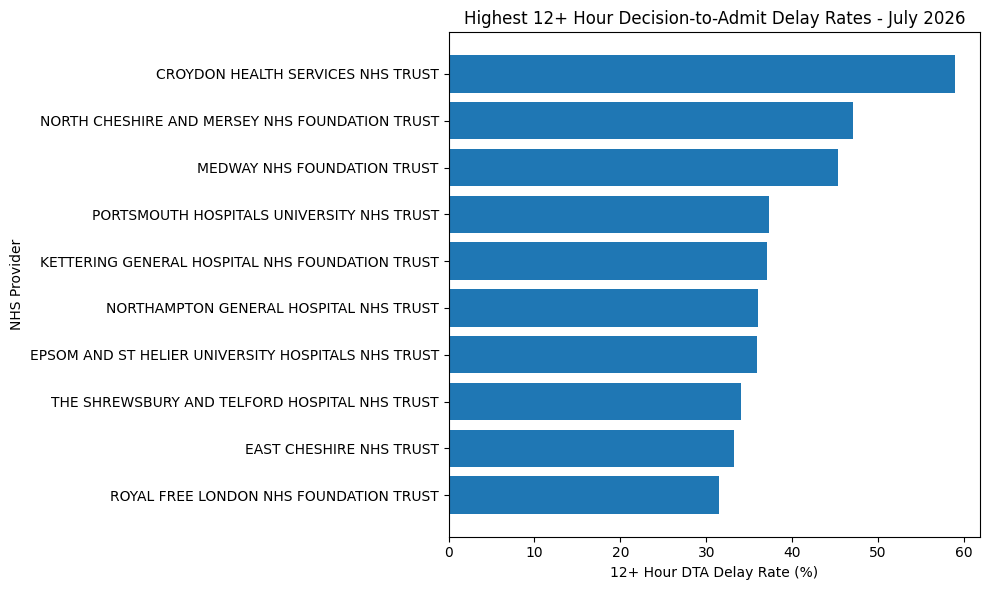

In [34]:
plt.figure(figsize=(10, 6))

plt.barh(highest_delay['Org name'], highest_delay['12+ Hour DTA Delay Rate %'])

plt.xlabel('12+ Hour DTA Delay Rate (%)')

plt.ylabel('NHS Provider')

plt.title('Highest 12+ Hour Decision-to-Admit Delay Rates - July 2026')

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

**Visualising 12+ Hour Admission Delays**

A horizontal bar chart was created to compare the ten providers with the highest derived 12+ hour decision to admit delay rates.

The percentage represents the number of patients waiting 12 hours or more following a decision to admit relative to the number of emergency admissions occurring via A&E.

A horizontal bar chart was selected to allow long NHS provider names to be displayed clearly.

This visualisation highlights substantial variation in prolonged admission delays between providers during July 2026.



The number of recorded 12+ hour DTA waits was equivalent to 58.9% of emergency admissions via A&E.

In [35]:
tableau_data = ae_clean[[

'Period',

'Org Code',

'Org name',

'Total A&E Attendances',

'Total Over 4 Hours',

'Within 4 Hours',

'4 Hour Performance %',

'Total Emergency Admissions',

'Emergency Admissions via A&E',

'Patients who have waited 4-12 hs from DTA to admission',

'Patients who have waited 12+ hrs from DTA to admission',

'Total DTA Over 4 Hours',

'12+ Hour DTA Delay Rate %',

'Type 1 Total Attendances',

'Type 1 Over 4 Hours',

'Type 1 Within 4 Hours',

'Type 1 4 Hour Performance %'

]].copy()


tableau_data.head()


tableau_data.shape

(191, 17)

**Preparing the Dataset for Tableau**

Following data cleaning, validation and exploratory analysis, a separate dataframe was created containing the variables required for dashboard development.

The final dataset includes provider identifiers, overall A&E activity, four hour performance, emergency admissions, decision to admit delays and Type 1 A&E performance measures.

Removing unnecessary intermediate variables creates a more concise dataset for visualisation while retaining the cleaned master dataset separately for reproducibility.

In [36]:
tableau_data.to_csv('NHS_AE_July_2026_Tableau.csv', index=False)

print("CSV saved successfully")

CSV saved successfully


**Exporting the Cleaned Dataset**

The final Tableau dataset was exported as a CSV file using the to_csv() function.

The index=False argument prevents the Pandas row index from being written into the exported dataset as an additional variable.

This creates a clean, portable dataset that can be imported directly into Tableau for dashboard development.

In [38]:
from google.colab import files

files.download('NHS_AE_July_2026_Tableau.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>